<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/13%EC%A3%BC%EC%B0%A8/data_preprocessing_visualization_statistics_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **자료 전처리(Data Preprocessin) 및 시각화 (Data Visualization)**

# **기술통계 분석**


In [ ]:
#  나의 드라이브를 마운트 해줘
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the path to the data directory in Google Drive
drive_data_path = '/content/drive/MyDrive/데이터분석입문/data'

import pandas as pd

df = pd.read_pkl(drive_data_path + '/df_cleaned.pkl')

In [ ]:
df

,Rental_Date,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days
236013,2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday
404498,2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday
...,...,...,...,...,...,...,...,...,...,...,...
1183410,2024-12-26,2104. 사당역 5번출구,정기권,M,40.0,1,167.66,1.28,5498.46,39,Thursday
174230,2024-12-04,3523. 건국대학교 과학관(이과대) 앞,정기권,M,40.0,1,64.33,0.48,2056.31,12,Wednesday
808455,2024-12-17,5333. 노원역9번-10번 출구 앞,정기권,M,40.0,1,75.91,0.49,2130.00,16,Tuesday
221279,2024-12-05,1135. 강서구의회,정기권,F,60.0,1,41.32,0.37,1605.09,8,Thursday


In [ ]:
# Rental_Date를 index로

df.set_index('Rental_Date', inplace=True)
display(df.head())

,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days
Rental_Date,,,,,,,,,,
2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday
2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday
2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday
2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday
2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday


In [ ]:
# 요일별 Rental_Count를 시각화

# Task
Visualize the total 'Rental_Count' by day of the week using a bar plot.

## Group and aggregate data

### Subtask:
Group the DataFrame by the 'days' column and calculate the sum of 'Rental_Count' for each day.


**Reasoning**:
Group the DataFrame by 'days' and sum 'Rental_Count' to get the total rental count for each day of the week.



In [ ]:
rental_count_by_day = df.groupby('days')['Rental_Count'].sum()
display(rental_count_by_day)

,Rental_Count
days,
Friday,159
Monday,202
Saturday,130
Sunday,96
Thursday,148
Tuesday,224
Wednesday,136


## Visualize data

### Subtask:
Create a bar plot to visualize the total 'Rental_Count' for each day of the week.


**Reasoning**:
Create a bar plot to visualize the total 'Rental_Count' for each day of the week and add labels and a title.



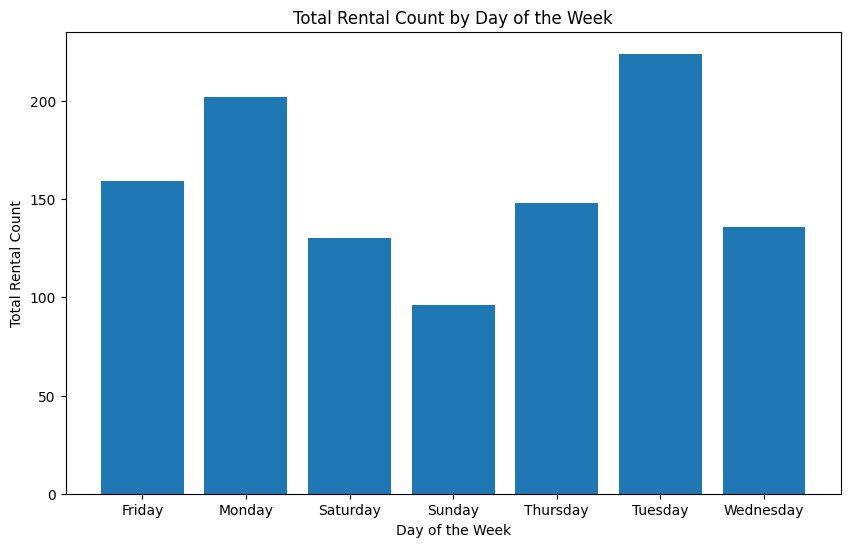

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(rental_count_by_day.index, rental_count_by_day.values)
plt.title("Total Rental Count by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Rental Count")
plt.show()

## Summary:

### Data Analysis Key Findings

*   The total rental count for each day of the week was calculated: Friday accounted for 159 rentals, Monday for 202, Saturday for 130, Sunday for 96, Thursday for 148, Tuesday for 224, and Wednesday for 136.
*   A bar plot was successfully generated to visualize the total rental count for each day of the week.

### Insights or Next Steps

*   Tuesday and Monday had the highest rental counts, while Sunday and Saturday had the lowest, indicating potential patterns in rental activity throughout the week.
*   Further analysis could explore the reasons for the higher rental counts on weekdays compared to weekends, perhaps by examining other factors like promotions or customer demographics.


In [ ]:
df.describe()

,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes
count,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000
mean,32.970149,1.634328,85.804104,0.731463,3152.788164,29.108955
std,14.650355,1.412844,102.461658,0.850553,3664.138509,38.800418
min,10.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,20.000000,1.000000,25.545000,0.220000,960.635000,7.000000
50%,30.000000,1.000000,50.700000,0.445000,1915.665000,15.000000
75%,40.000000,2.000000,97.122500,0.850000,3676.127500,38.000000
max,70.000000,16.000000,707.300000,6.320000,27233.540000,395.000000


In [ ]:
# Exercise_Amount, Carbon_Amount, Distance_M의 median, mode를 구해줘

columns_to_analyze = ['Exercise_Amount', 'Carbon_Amount', 'Distance_M']

print("Median:")
display(df[columns_to_analyze].median())

print("\nMode:")
display(df[columns_to_analyze].mode())

Median:


,0
Exercise_Amount,50.700
Carbon_Amount,0.445
Distance_M,1915.665



Mode:


,Exercise_Amount,Carbon_Amount,Distance_M
0,0.0,0.0,0.0


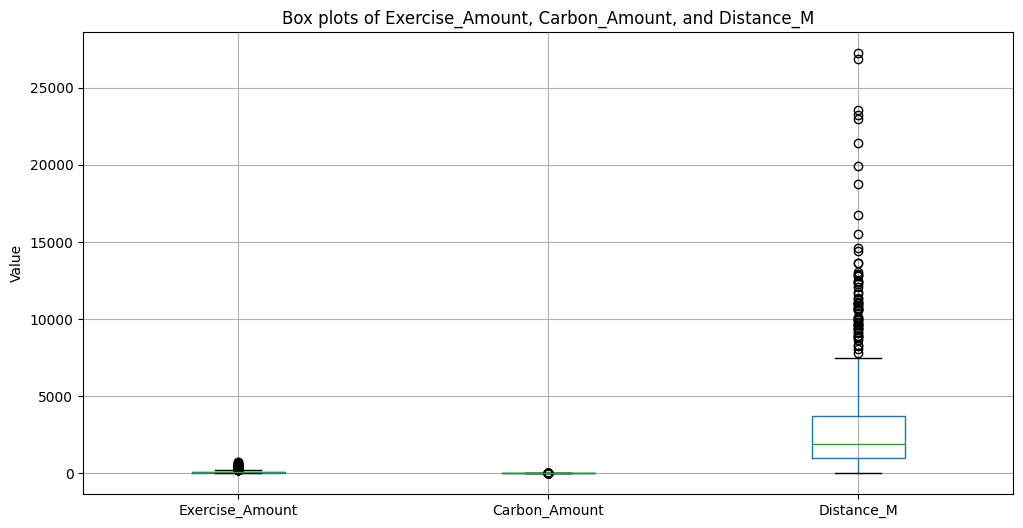

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df[columns_to_analyze].boxplot()
plt.title('Box plots of Exercise_Amount, Carbon_Amount, and Distance_M')
plt.ylabel('Value')
plt.show()

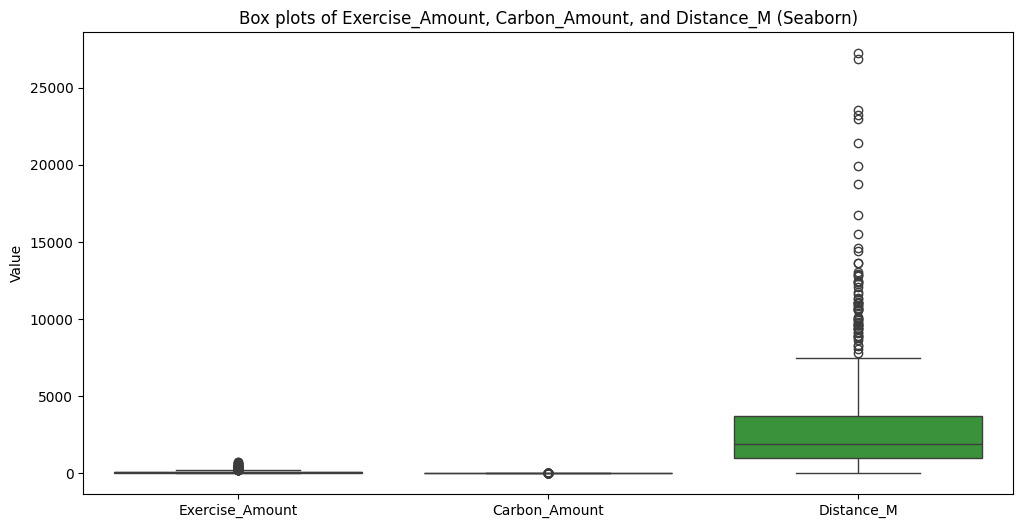

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[columns_to_analyze])
plt.title('Box plots of Exercise_Amount, Carbon_Amount, and Distance_M (Seaborn)')
plt.ylabel('Value')
plt.show()

# columns_to_analyze의 컬럼을 평균을 0 분산은 1로 자료표준화이후 막대상자를 그려줘

## Standardize data

### Subtask:
Standardize the columns in `columns_to_analyze` to have a mean of 0 and a variance of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[columns_to_analyze] = scaler.fit_transform(df[columns_to_analyze])

display(df_scaled[columns_to_analyze].head())

,Exercise_Amount,Carbon_Amount,Distance_M
Rental_Date,,,
2024-12-05,-0.682170,-0.695905,-0.691753
2024-12-09,-0.719187,-0.684139,-0.686291
2024-12-12,-0.578737,-0.601779,-0.599529
2024-12-16,-0.527363,-0.566481,-0.568566
2024-12-05,-0.343547,-0.248804,-0.241582


## Visualize standardized data

### Subtask:
Create box plots for the standardized columns.

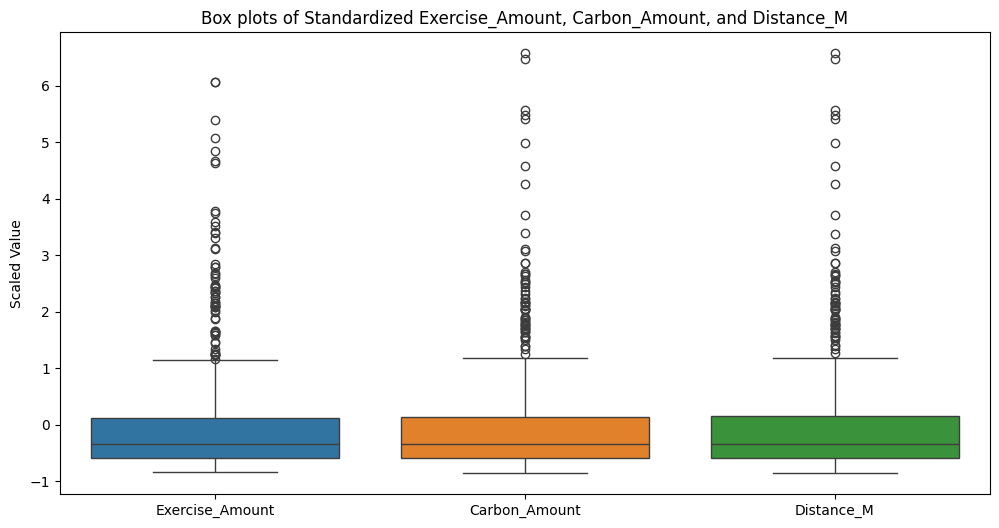

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled[columns_to_analyze])
plt.title('Box plots of Standardized Exercise_Amount, Carbon_Amount, and Distance_M')
plt.ylabel('Scaled Value')
plt.show()

In [ ]:
df.columns

Index(['Rental_Station', 'Rental_Type_Code', 'Gender', 'Age_Group',
       'Rental_Count', 'Exercise_Amount', 'Carbon_Amount', 'Distance_M',
       'Duration_Minutes', 'days'],
      dtype='object')

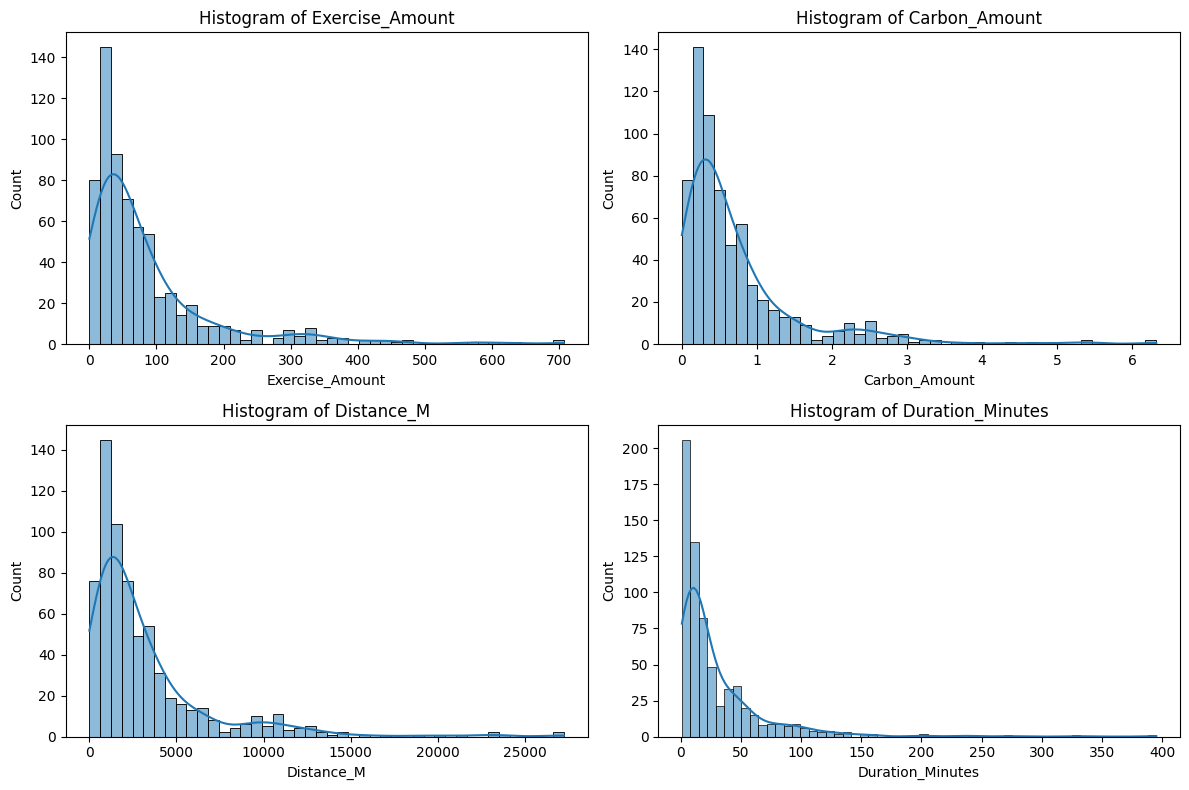

In [ ]:
# df의 'Exercise_Amount', 'Carbon_Amount', 'Distance_M', 'Duration_Minutes' 의 히스토그램을 sns로 시각화해줘

columns_for_histograms = ['Exercise_Amount', 'Carbon_Amount', 'Distance_M', 'Duration_Minutes']

plt.figure(figsize=(12, 8))
for i, col in enumerate(columns_for_histograms):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# columns_for_histograms의 컬럼값의 skenewss를 구해줘

print("Skewness:")
display(df[columns_for_histograms].skew())

Skewness:


,0
Exercise_Amount,2.721946
Carbon_Amount,2.870563
Distance_M,2.870492
Duration_Minutes,3.786387


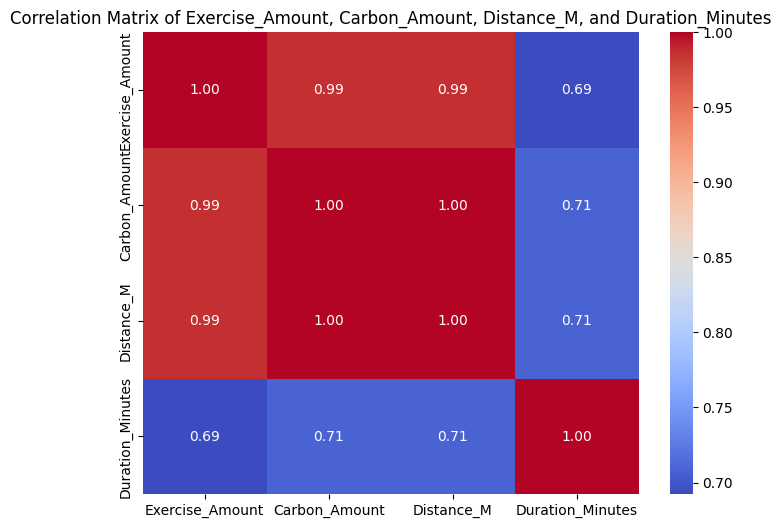

In [ ]:
# columns_for_histograms 의 상관관계를 구하고 시각화해줘

correlation_matrix = df[columns_for_histograms].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Exercise_Amount, Carbon_Amount, Distance_M, and Duration_Minutes')
plt.show()

In [ ]:
df

,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days
Rental_Date,,,,,,,,,,
2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday
2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday
2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday
2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday
2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday
...,...,...,...,...,...,...,...,...,...,...
2024-12-26,2104. 사당역 5번출구,정기권,M,40.0,1,167.66,1.28,5498.46,39,Thursday
2024-12-04,3523. 건국대학교 과학관(이과대) 앞,정기권,M,40.0,1,64.33,0.48,2056.31,12,Wednesday
2024-12-17,5333. 노원역9번-10번 출구 앞,정기권,M,40.0,1,75.91,0.49,2130.00,16,Tuesday


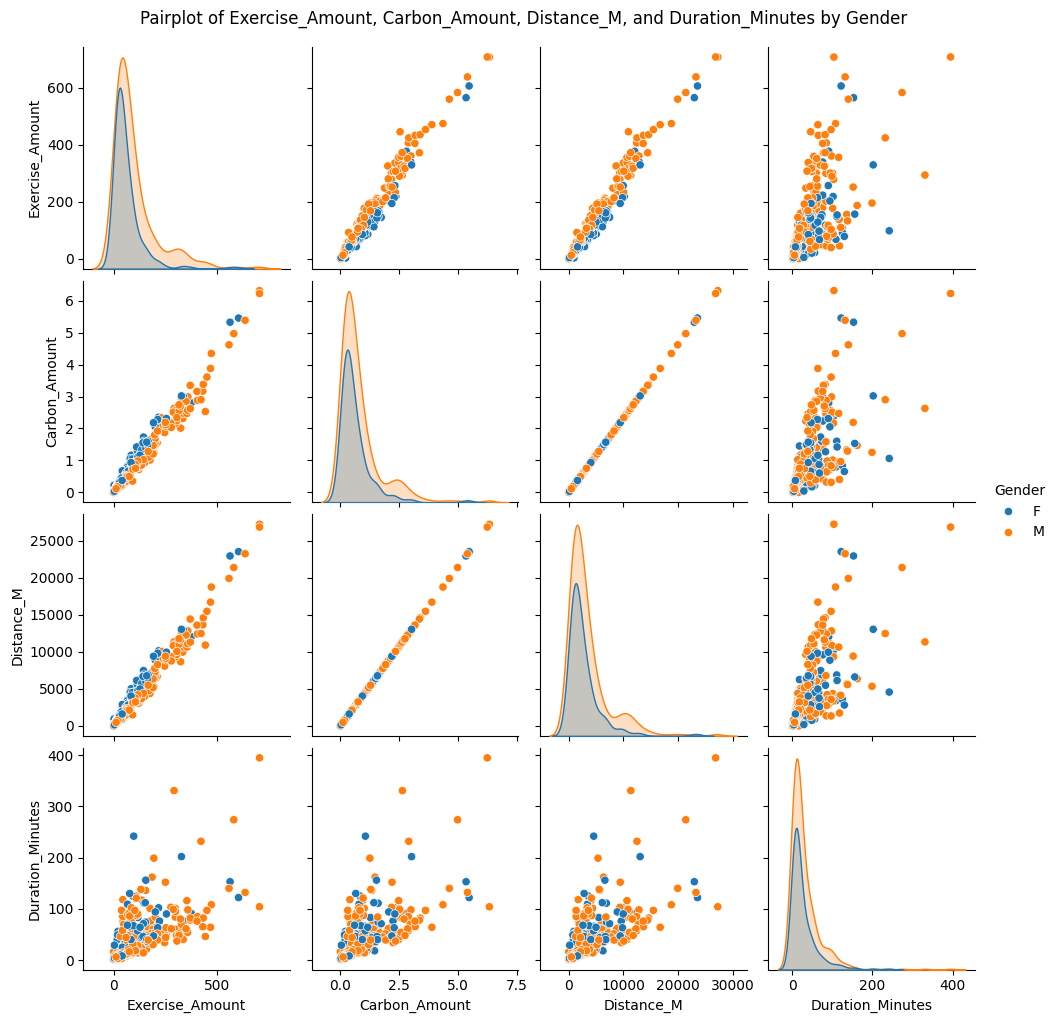

In [ ]:
# pairplot을 그려줘 남녀를 구분하여서

columns_for_pairplot = ['Exercise_Amount', 'Carbon_Amount', 'Distance_M', 'Duration_Minutes']

sns.pairplot(df[columns_for_pairplot + ['Gender']], hue='Gender')
plt.suptitle('Pairplot of Exercise_Amount, Carbon_Amount, Distance_M, and Duration_Minutes by Gender', y=1.02)
plt.show()

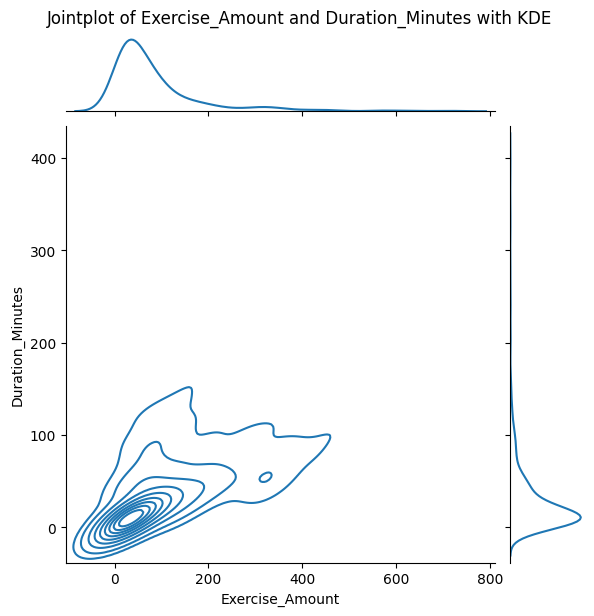

In [ ]:
# jointplot을 임의의 두변수를 선택하여 kde를 적용하여 시각화

# Select two arbitrary variables for the jointplot
variable1 = 'Exercise_Amount'
variable2 = 'Duration_Minutes'

sns.jointplot(data=df, x=variable1, y=variable2, kind='kde')
plt.suptitle(f'Jointplot of {variable1} and {variable2} with KDE', y=1.02)
plt.show()

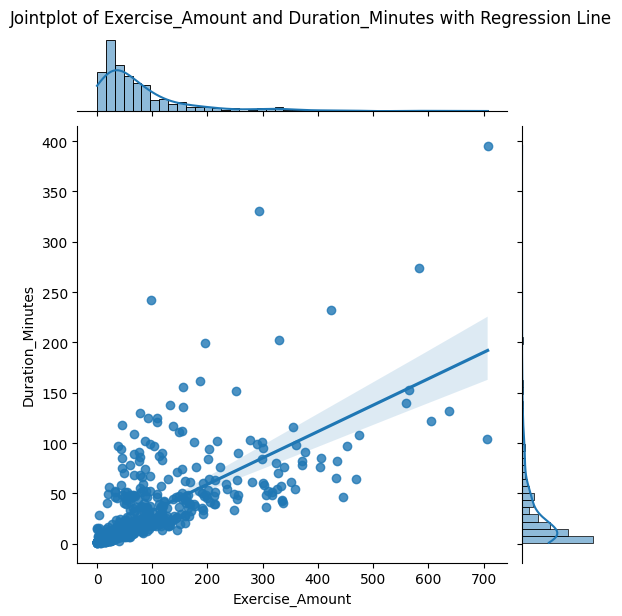

In [ ]:
# Select two arbitrary variables for the jointplot
variable1 = 'Exercise_Amount'
variable2 = 'Duration_Minutes'

sns.jointplot(data=df, x=variable1, y=variable2, kind='reg')
plt.suptitle(f'Jointplot of {variable1} and {variable2} with Regression Line', y=1.02)
plt.show()

In [ ]:
df.head()

,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days
Rental_Date,,,,,,,,,,
2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday
2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday
2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday
2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday
2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday


## **folium 지도 시각화**

In [ ]:
# df 컬럼에 임의의 위도와 경도를 대한민국 서울에 있는 10개 지역으로 생성해줘

# Approximate coordinates for 30 arbitrary locations in Seoul
seoul_locations = [
    (37.5665, 126.9780), # Seoul City Hall
    (37.5519, 126.9918), # Namsan Tower
    (37.5750, 126.9769), # Gyeongbokgung Palace
    (37.5660, 127.0084), # Dongdaemun Design Plaza
    (37.5360, 126.9924), # Itaewon
    (37.5112, 127.0534), # Gangnam Station
    (37.5088, 127.0637), # COEX Aquarium
    (37.5495, 127.0752), # Seoul Forest
    (37.5802, 127.0099), # Changdeokgung Palace
    (37.5135, 126.9940),  # Banpo Bridge
    # Added 20 more arbitrary locations in Seoul
    (37.5576, 126.9264), # Hongdae Area
    (37.5838, 127.0565), # Korea University
    (37.4981, 127.0276), # Gangnam Station Area
    (37.5601, 126.9371), # Ewha Womans University Area
    (37.5433, 127.0591), # Konkuk University Area
    (37.5509, 127.0718), # Children's Grand Park
    (37.5801, 126.9894), # Bukchon Hanok Village
    (37.5285, 126.9650), # Yeouido Park
    (37.5174, 127.0423), # Samseong Station Area
    (37.5555, 126.8986), # Mokdong Area
    (37.6066, 127.0417), # Changdong Area
    (37.5030, 127.1116), # Jamsil Area
    (37.5317, 127.1200), # Olympic Park
    (37.4839, 127.0378), # Seoul National University Area
    (37.5728, 127.0168), # Sungkyunkwan University Area
    (37.5871, 127.0784), # Hankuk University of Foreign Studies Area
    (37.5482, 127.0007), # Sookmyung Women's University Area
    (37.5637, 126.9032), # Seodaemun Area
    (37.5144, 127.1030), # Gangbyeon Station Area
    (37.5790, 126.8844)  # Digital Media City Area
]

# Create lists for Latitude and Longitude
latitudes = [loc[0] for loc in seoul_locations]
longitudes = [loc[1] for loc in seoul_locations]

# Assign coordinates to the DataFrame rows cyclically
num_rows = len(df)
num_locations = len(seoul_locations)

df['Latitude'] = [latitudes[i % num_locations] for i in range(num_rows)]
df['Longitude'] = [longitudes[i % num_locations] for i in range(num_rows)]

display(df.head())

,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days,Latitude,Longitude
Rental_Date,,,,,,,,,,,,
2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday,37.5665,126.9780
2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday,37.5519,126.9918
2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday,37.5750,126.9769
2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday,37.5660,127.0084
2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday,37.5360,126.9924


In [ ]:
import folium

m = folium.Map(location=[37.5758699,126.9811831], zoom_start=12)
folium.Marker(location=[37.5758699,126.9811831],
              popup='을지로',
              icon=folium.Icon(color='blue',icon='star')
              ).add_to(m)
m

In [ ]:
# df의 위경도별로 Exercise_Amount의 평균을 구하고 평균의 크기를 원의 크기로 표시하는 folium에 지도 시각화해줘


# Group by Latitude and Longitude and calculate the mean of Exercise_Amount
avg_exercise_by_location = df.groupby(['Latitude', 'Longitude'])['Exercise_Amount'].mean().reset_index()

# Create a folium map centered around Seoul
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# Add circle markers for each location with radius based on average Exercise_Amount
# Scale the Exercise_Amount for better visualization as radius
max_exercise = avg_exercise_by_location['Exercise_Amount'].max()
min_exercise = avg_exercise_by_location['Exercise_Amount'].min()

# Define a scaling factor or function to map average exercise amount to radius
# A simple linear scaling can be used, or a more sophisticated one
def scale_radius(avg_exercise, min_val, max_val, min_radius=5, max_radius=20):
    if max_val == min_val:
        return min_radius
    return min_radius + (avg_exercise - min_val) / (max_val - min_val) * (max_radius - min_radius)


for index, row in avg_exercise_by_location.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=scale_radius(row['Exercise_Amount'], min_exercise, max_exercise),
        popup=f"Avg Exercise Amount: {row['Exercise_Amount']:.2f}",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(m)

# Display the map
m